# Cyber Risk Control ROI + Sensitivity Analysis

This notebook evaluates how cyber control effectiveness changes financial outcomes.

It extends scenario-based modeling by:
- Measuring ROI stability
- Testing sensitivity to key variables
- Identifying key drivers of risk reduction

Goal:
Understand not just *if* a control works, but *why* it works.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
base_params = {
    "ransomware_tef": (1, 3, 6),
    "loss_mean": 14.5,
    "loss_sigma": 0.7,
    "control_cost": 1_000_000
}

In [3]:
def simulate_ransomware(control_reduction=0.0):
    tef = np.random.triangular(
        base_params["ransomware_tef"][0] * (1 - control_reduction),
        base_params["ransomware_tef"][1] * (1 - control_reduction),
        base_params["ransomware_tef"][2] * (1 - control_reduction),
        10000
    )
    
    loss = np.random.lognormal(
        mean=base_params["loss_mean"],
        sigma=base_params["loss_sigma"],
        size=10000
    )
    
    return tef * loss

In [4]:
control_levels = [0.0, 0.2, 0.4, 0.6, 0.8]

results = {}

for c in control_levels:
    results[c] = simulate_ransomware(control_reduction=c)

In [5]:
roi_results = []

baseline = np.percentile(results[0.0], 50)

for c, ale in results.items():
    controlled = np.percentile(ale, 50)
    
    risk_reduction = baseline - controlled
    benefit = risk_reduction
    cost = base_params["control_cost"]
    
    roi = (benefit - cost) / cost
    
    roi_results.append({
        "Control Reduction": c,
        "Risk Reduction ($)": risk_reduction,
        "ROI": roi
    })

df = pd.DataFrame(roi_results)
df

,Control Reduction,Risk Reduction ($),ROI
0,0.0,0.000000e+00,-1.000000
1,0.2,1.305118e+06,0.305118
2,0.4,2.469215e+06,1.469215
3,0.6,3.774382e+06,2.774382
4,0.8,5.035726e+06,4.035726


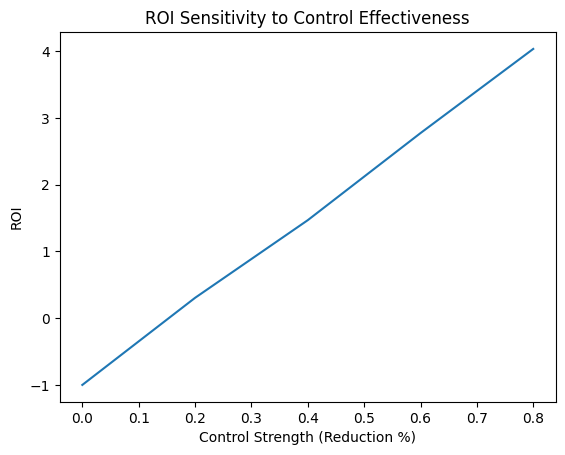

In [6]:
plt.plot(df["Control Reduction"], df["ROI"])
plt.title("ROI Sensitivity to Control Effectiveness")
plt.xlabel("Control Strength (Reduction %)")
plt.ylabel("ROI")
plt.show()

## Key Insight

- ROI is highly sensitive to control effectiveness
- Small improvements in control strength significantly impact financial return
- Cyber investments should be evaluated as *range-based decisions*, not point estimates

Implication:
Security investment decisions should incorporate uncertainty and sensitivity, not static ROI values.